## RQ8: How does the venue capacity influence the win rate of the away team for the seasons 2022-2024?

In [1]:
import requests
import matplotlib.pyplot as plt
from requests.auth import HTTPBasicAuth
header = {'x-apisports-key': 'dfb3ecf3de2f46a60337771460282483'}

In [ ]:
# teamID_football.api: teamID_api.openliga

teamIDmapper = {
    '157': 40,      # München
    '160': 112,     # Freiburg
    '161': 131,     # Wolfsburg
    '162': 134,     # Bremen
    '163': 87,      # Mönchengladbach
    '164': 81,      # Mainz
    '165': 7,       # Dortmund
    '167': 175,     # Hoffenheim
    '168': 6,       # Leverkusen
    '169': 91,      # Frankfurt
    '170': 95,      # Augsburg
    '172': 16,      # Stuttgart
    '173': 1635,    # Leipzig
    '176': 129,     # Bochum
    '180': 199,     # Heidenheim
    '182': 80,      # Union Berlin
    '186': 98,      # St. Pauli
    '191': 104,     # Holstein Kiel
    '1660': None    # not in 1bl
}

In [ ]:
# all venues of 2022-2024
venues = [[], []]
# [] teamID home team, [] venue capacity

for x in range(3):
    season = 2022 + x
    url = "https://v3.football.api-sports.io/teams?league=78&season=" + str(season)
    response = requests.get(url, headers=header)
    response = response.json()

response ['response']

for team_venue in response ['response']:
    teamIDfb = str(team_venue ['team'] ['id'])
    teamID = teamIDmapper [teamIDfb]
    if teamID not in venues[0]:
        venues[0] += [teamID]       
        venues[1] += [team_venue ['venue'] ['capacity']]

# no venue for Schalke, Herta, Köln, Darmstadt --> add manually from wikipedia 
venues[0].append(9)         # Schalke
venues[1].append(62271)
venues[0].append(54)        # Herta
venues[1].append(74475)
venues[0].append(65)        # Köln
venues[1].append(50000)
venues[0].append(118)       # Darmstadt
venues[1].append(17810)

In [24]:
result = [[], [], [], [], []]
# [0] teamID home team, [1] matches win away team, [2] matches draw&loss away team,
# [3] venue size, [4] win rate away team

# get all matchIDs for 2022-2024
matchIDs = []
for x in range(3):
    season = 2022 + x
    url = "https://api.openligadb.de/getmatchdata/bl1/" + str(season)
    response = requests.get(url)
    response = response.json()
    for match in response:
        matchID = match ['matchID']
        matchIDs.append(matchID)

# get all teamIDs
for matchID in matchIDs:
    # get match 
    url = "https://api.openligadb.de/getmatchdata/"
    url += str(matchID)
    match = requests.get(url)
    match = match.json()

    # get teamID home team, if new add to result
    teamID1 = match ['team1'] ['teamId']
    if teamID1 not in result[0]:
        matchID = match ['matchID']
        result[0] += [teamID1]
        result[1] += [0]
        result[2] += [0]
        index = venues[0].index(teamID1)
        capacity = venues [1] [index]
        result[3] += [capacity]
        result[4] += [0]

    # did away team win or not?
    matchResult = match ['matchResults'] [0]
    if matchResult ['pointsTeam2'] == 3:        
        index = result [0].index(teamID1)
        result [1] [index] += 1     # win away team
    else:       
        index = result [0].index(teamID1)
        result [2] [index] += 1     # draw or loss away team

# get win rate away team
for index in range(len(result[0])):
    wins_away = int(result[1] [index])
    no_wins_away = int(result[2] [index])
    result[4] [index] = [ 100 * (wins_away / (wins_away + no_wins_away))]

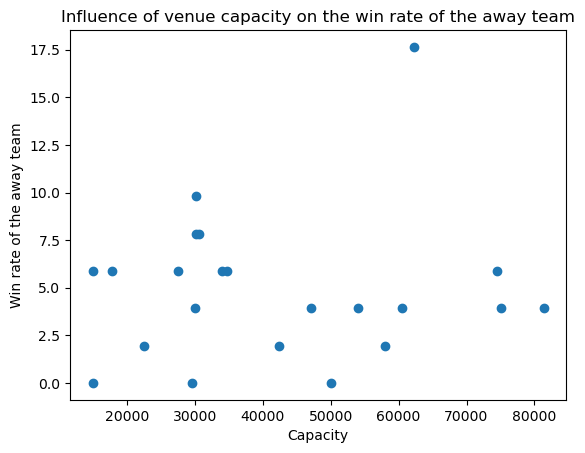

In [26]:
x = result[3]
y = result[4]
plt.scatter(x,y)
plt.title('Influence of venue capacity on the win rate of the away team')
plt.xlabel('Capacity')
plt.ylabel('Win rate of the away team')
plt.show()